In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def boxplot_fxs(fxs, N_expected, instancia):
    fxs = np.array(fxs)
    mean = fxs.mean()
    std = fxs.std()
    N = len(fxs)
    

    plt.figure(figsize=(6, 4))
    sns.boxplot(x=fxs, color="#4C72B0")

    text = (
        f"N = {N}/{N_expected}\n"
        f"$\\bar{{x}}$ = {mean:.4f}\n"
        f"$\\sigma$ = {std:.4f}"
    )

    plt.text(
        0.98, 0.98,
        text,
        ha='right',
        va='top',
        transform=plt.gca().transAxes,
        fontsize=11,
        bbox=dict(facecolor='white', alpha=0.7, edgecolor='gray')
    )

    plt.xlabel("fx values")
    plt.title(f"Distribuição das avaliações (fx) - Instância: {instancia}")
    plt.tight_layout()
    plt.show()

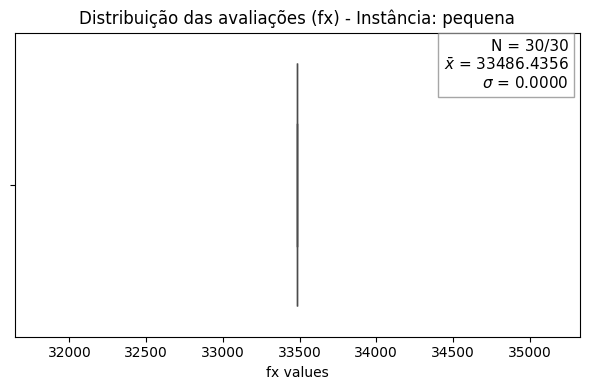

In [4]:
from djavan import resolva
from dados import carrega_dados_json

fxs = []
iteracoes = 30

for instancia in ["pequena", "media", "grande", "rush"]:
    dados = carrega_dados_json(f"./dados/{instancia}.json")
    for i in range(iteracoes):
        sol = resolva(dados, 10*dados.n*dados.K*dados.r)
        if sol.factivel(dados):
            fxs.append(sol.fx)
    boxplot_fxs(fxs, iteracoes, instancia)